In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('superstore.csv', encoding='latin-1')

# Clean column names
df.columns = df.columns.str.strip()

print('Dataset loaded successfully')
print("Columns:", df.columns.tolist())
print(df.head())

Saving superstore.csv to superstore.csv
Dataset loaded successfully
Columns: ['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales']
   Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode Customer_ID  \
0       1  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688   12/6/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer_Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Hend

In [ ]:
print(df.info())

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("Summary Statistics")
print(df.describe())

print("Missing Values")
print(df.isnull().sum())

print(f"Mean Sales: ${df['Sales'].mean():.2f}")
print(f"Median Sales: ${df['Sales'].median():.2f}")
print(f"Mode Sales: ${df['Sales'].mode()[0]:.2f}")
print(f"Total Sales: ${df['Sales'].sum():.2f}")
print(f"Max Sales: ${df['Sales'].max():.2f}")
print(f"Min Sales: ${df['Sales'].min():.2f}")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

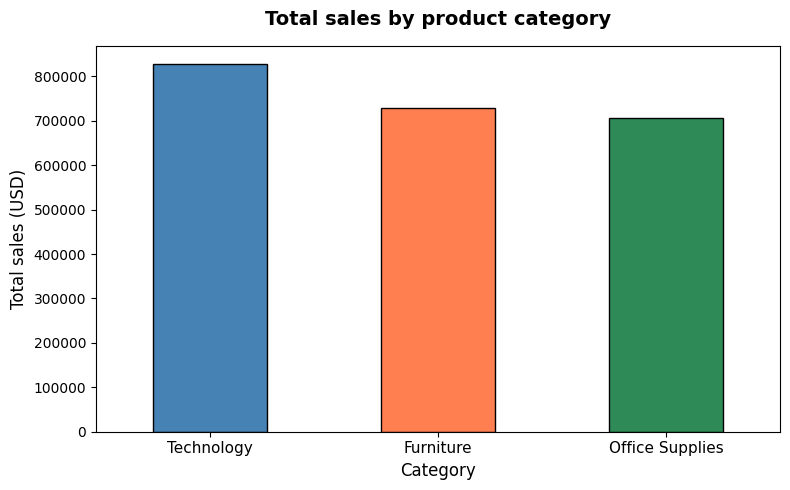

In [ ]:
# Chart1: Bar Chart (Sales by Category)
plt.figure(figsize=(8,5))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales.plot(kind='bar', color=['steelblue', 'coral', 'seagreen'], edgecolor='black')

plt.title('Total sales by product category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total sales (USD)', fontsize=12)
plt.xticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig('chart1_bar.png', dpi=150)
plt.show()

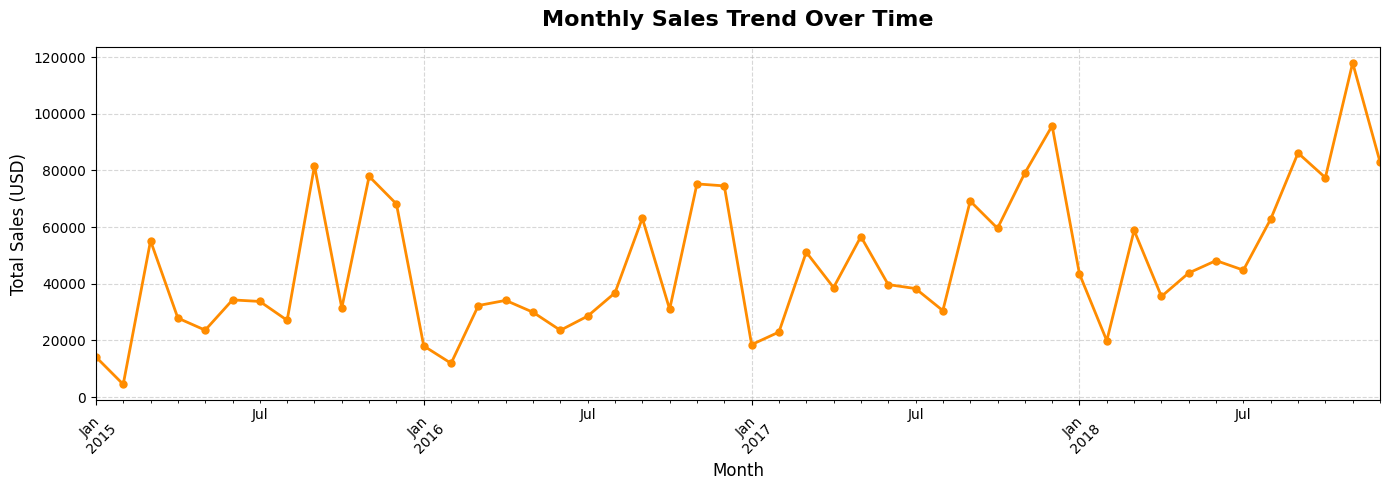

In [ ]:
# Chart2: Line Chart(Monthly Sales Trend)

df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Month'] = df['Order_Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(kind='line', color='darkorange', marker='o', linewidth=2, markersize=5)

plt.title('Monthly Sales Trend Over Time', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_line.png', dpi=150)
plt.show()


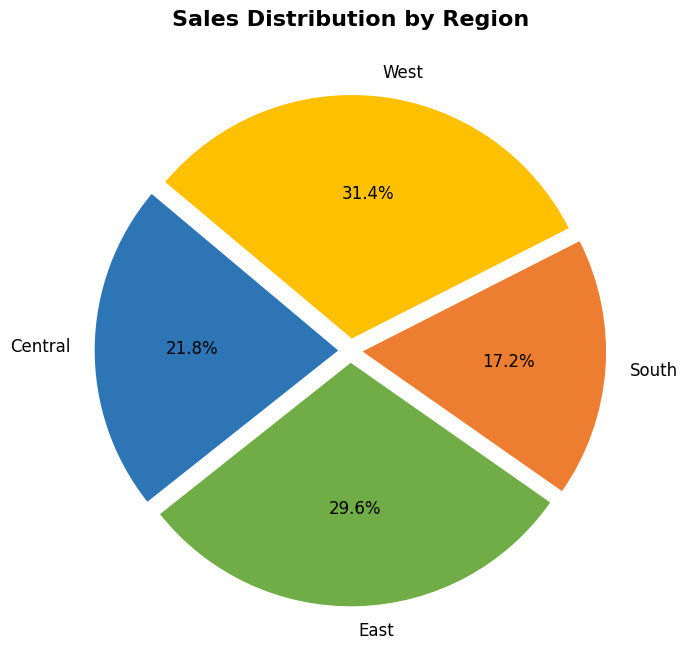

In [ ]:
# Chart3: Pie Chart(Sales by Region)

plt.figure(figsize=(7, 7))
region_sales = df.groupby('Region')['Sales'].sum()
colors = ['#2E75B6', '#70AD47', '#ED7D31', '#FFC000']
explode = [0.05] * len(region_sales)

plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%',
        startangle=140, colors=colors, explode=explode,
        textprops={'fontsize': 12})

plt.title('Sales Distribution by Region', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart3_pie.png', dpi=150)
plt.show()


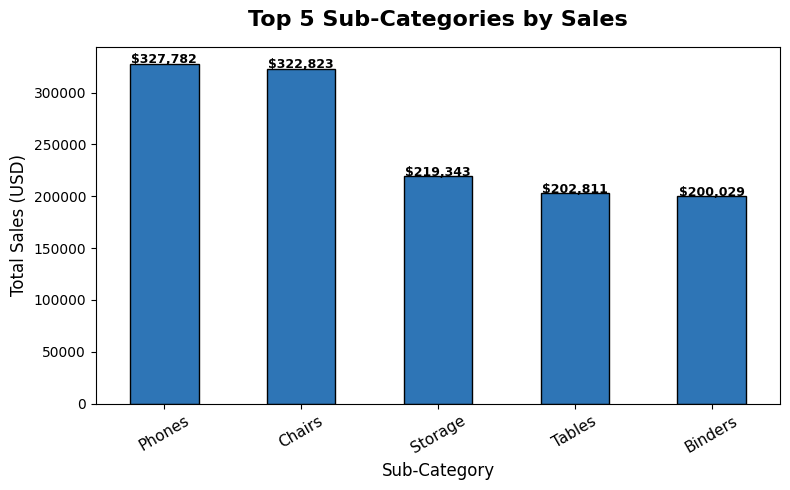

In [ ]:
# Top 5 sub-categories by sales

plt.figure(figsize=(8, 5))
sub_sales = df.groupby('Sub_Category')['Sales'].sum().sort_values(ascending=False).head(5)
sub_sales.plot(kind='bar', color='#2E75B6', edgecolor='black')

plt.title('Top 5 Sub-Categories by Sales', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Sub-Category', fontsize=12)
plt.ylabel('Total Sales (USD)', fontsize=12)
plt.xticks(rotation=30, fontsize=11)

for i, v in enumerate(sub_sales):
    plt.text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('chart4_sub.png', dpi=150)
plt.show()


In [ ]:
from google.colab import files
files.download('chart1_bar.png')
files.download('chart2_line.png')
files.download('chart3_pie.png')
files.download('chart4_sub.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>